### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [160]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.preprocessing import StandardScaler

In [4]:
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader

In [38]:
import torchinfo
import torchview

### Step 2: Constant

In [239]:
FILE_PATH = './data/household_power_consumption.txt'
TRAIN_RATE = 0.7
VALUE_RATE = 0.15
PREDICT_COL = 'Global_active_power'
BATCH_SIZE = 128
WINDOW_SIZE = 72
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAIN_COLOR = "#2c3e50"
VALID_COLOR = "#e74c3c"

### Step 3: Load Data

In [6]:
df = pd.read_csv(
    FILE_PATH, 
    sep=';',
    parse_dates={'datetime': ['Date', 'Time']},
    na_values='?'
)

In [7]:
df.set_index('datetime', inplace=True)

In [8]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


### Step 4: Exploaring Data

#### Basic Info

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Global_active_power,2049280.0,1.091615,1.057294,0.076,0.308,0.602,1.528,11.122
Global_reactive_power,2049280.0,0.123714,0.112722,0.000,0.048,0.100,0.194,1.390
Voltage,2049280.0,240.839858,3.239987,223.200,238.990,241.010,242.890,254.150
Global_intensity,2049280.0,4.627759,4.444396,0.200,1.400,2.600,6.400,48.400
Sub_metering_1,2049280.0,1.121923,6.153031,0.000,0.000,0.000,0.000,88.000
Sub_metering_2,2049280.0,1.298520,5.822026,0.000,0.000,0.000,1.000,80.000
Sub_metering_3,2049280.0,6.458447,8.437154,0.000,0.000,1.000,17.000,31.000


In [10]:
feature_info = pd.DataFrame(
    {
        'null': df.isnull().sum(),
        'null(%)': round(100*df.isnull().sum()/len(df), 2),
        'unique': df.nunique(),
        'type': df.dtypes
    }
)

In [11]:
feature_info

,null,null(%),unique,type
Global_active_power,25979,1.25,4186,float64
Global_reactive_power,25979,1.25,532,float64
Voltage,25979,1.25,2837,float64
Global_intensity,25979,1.25,221,float64
Sub_metering_1,25979,1.25,88,float64
Sub_metering_2,25979,1.25,81,float64
Sub_metering_3,25979,1.25,32,float64


### Step 5: Preprocess Data

#### Data Clean

In [12]:
df = df.interpolate(method='time')

In [13]:
df = df.resample('H').mean()

In [14]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


#### Split Data

In [15]:
train_size = int(len(df) * TRAIN_RATE)
val_size = int(len(df) * VALUE_RATE)

In [16]:
train = df[:train_size]
value = df[train_size: train_size+val_size]
test = df[train_size+val_size:]

#### Scaler Data

In [17]:
X_scaler = StandardScaler()
y_scaler = StandardScaler()

In [18]:
X_scaler.fit(train)

,copy,True
,with_mean,True
,with_std,True


In [19]:
y_scaler.fit(train[[PREDICT_COL]])

,copy,True
,with_mean,True
,with_std,True


#### Build Dataset

In [21]:
class TimeSeriesDataset(Dataset):
    def __init__(self, df, target_col, X_scaler, y_scaler, window_size=24, horizon=1):
        self.df = df
        if isinstance(target_col, str):
            try:
                self.target_col = df.columns.get_loc(target_col)
            except:
                raise NotImplementedError(f'target col ({target_col}) is not exist')
        else:
            self.target_col = target_col
        self.X_scaler = X_scaler
        self.y_scaler = y_scaler
        self.window_size = window_size
        self.horizon = horizon

    def __len__(self):
        return len(self.df) - self.window_size - self.horizon + 1

    def __getitem__(self, idx):
        x = self.df.iloc[idx : idx + self.window_size]
        x = self.X_scaler.transform(x)

        y = self.df.iloc[
            idx + self.window_size :
            idx + self.window_size + self.horizon,
            [self.target_col]
        ]
        y = self.y_scaler.transform(y).flatten()

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)

        return x, y

In [240]:
dataset_train = TimeSeriesDataset(train, PREDICT_COL, X_scaler, y_scaler, window_size=WINDOW_SIZE)
dataset_valid = TimeSeriesDataset(value, PREDICT_COL, X_scaler, y_scaler, window_size=WINDOW_SIZE)
dataset_test = TimeSeriesDataset(test, PREDICT_COL, X_scaler, y_scaler, window_size=WINDOW_SIZE)

In [241]:
x, y = dataset_train[0]

In [242]:
x.shape, y.shape

(torch.Size([72, 7]), torch.Size([1]))

#### Build Dataloader

In [243]:
dataloader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)
dataloader_valid = DataLoader(dataset_valid, batch_size=BATCH_SIZE, shuffle=False)
dataloader_test = DataLoader(dataset_test, batch_size=BATCH_SIZE, shuffle=False)

In [244]:
batch = next(iter(dataloader_train))

In [245]:
batch[0].shape, batch[1].shape

(torch.Size([128, 72, 7]), torch.Size([128, 1]))

### Step 5: Model Development

#### Build Model

In [246]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, out_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=False,
            dropout=dropout if num_layers > 1 else 0,
        )

        self.fc = nn.Linear(hidden_size, out_size)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.lstm(x)

        out = out[:, -1, :]

        out = self.fc(out)
        return out

In [266]:
model = LSTMModel(7)

In [267]:
torchinfo.summary(
    model,
    input_data={
        'x': batch[0]
    }
)

Layer (type:depth-idx)                   Output Shape              Param #
LSTMModel                                [128, 1]                  --
├─LSTM: 1-1                              [128, 72, 64]             51,968
├─Linear: 1-2                            [128, 1]                  65
Total params: 52,033
Trainable params: 52,033
Non-trainable params: 0
Total mult-adds (M): 478.95
Input size (MB): 0.26
Forward/backward pass size (MB): 4.72
Params size (MB): 0.21
Estimated Total Size (MB): 5.19

In [268]:
graph = torchview.draw_graph(
    model, 
    input_data={
        'x': batch[0]
    },
    expand_nested=True
)

In [269]:
g = graph.visual_graph
g.graph_attr['fontname'] = 'Arial'
g.node_attr['fontname'] = 'Arial'
g.edge_attr['fontname'] = 'Arial'
g.graph_attr['dpi'] = '80'

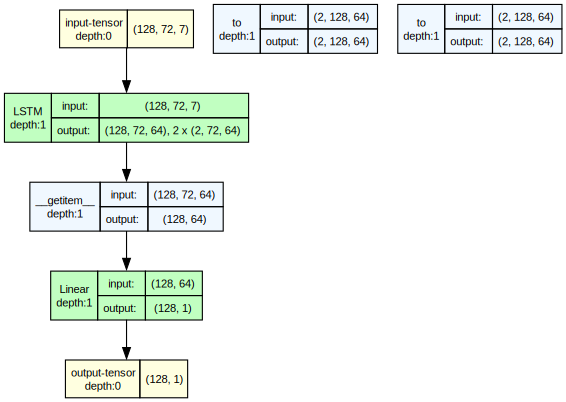

In [270]:
g

In [271]:
optimizer = optim.AdamW(model.parameters(), lr=1e-5)

In [272]:
criterion = nn.HuberLoss()

In [273]:
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=5,
    verbose=False
)

#### Train Model

In [274]:
def run(model, dataloader, criterion, optimizer=None, device='cpu', is_train=True, out_preds=False):
    if is_train:
        model.train()
    else:
        model.eval()
        
    total_loss = 0
    total_num = 0
    if out_preds:
        total_preds = list()

    for batch in dataloader:
        batch = [r.to(device) for r in batch]
        x, y = batch

        if is_train:
            if optimizer is None:
                raise NotImplementedError("if is_train is True, optimizer shouldn't be None")
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            preds = model(x) 
            loss = criterion(preds, y)

            if is_train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_num += x.size(0)
        if out_preds:
            total_preds.append(preds.detach().cpu())
      
    avg_loss = total_loss / total_num
    if out_preds:
        total_preds = torch.cat(total_preds, dim=0)
        return avg_loss, total_preds
    return avg_loss

In [275]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler=None, device='cpu', num_epochs=5, patience=10):
    best_val_loss = float('inf')
    no_improve_count = 0
    best_model_state = model.state_dict()
    history = {
        'loss': list(),
        'val_loss': list()
    }

    total_start_time = time.time()
    
    for epoch in range(1, num_epochs + 1):
        epoch_start_time = time.time()
        print(f"\nEpoch {epoch}/{num_epochs}")
        print("-" * 30)
        # 训练
        train_loss = run(model, train_loader, criterion, optimizer, device, is_train=True)
        print(f"Train Loss: {train_loss:.4f}", end='\t')
        history['loss'].append(train_loss)
        
        # 验证
        val_loss = run(model, val_loader, criterion, device, is_train=False)
        print(f"Val Loss: {val_loss:.4f}", end='\t')
        history['val_loss'].append(val_loss)

        # 调整学习率
        if scheduler is not None:
            scheduler.step(val_loss)
        
        # 保存最佳模型
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve_count = 0
        else:
            no_improve_count += 1

        epoch_time = time.time() - epoch_start_time
        print(f'Epoch Time: {epoch_time:.2f} sec')

        if no_improve_count >= patience:
            print(f"EarlyStopping triggered. No improvement in {patience} epochs.")
            break

    total_time = time.time() - total_start_time
    print(f"\nTraining complete. Best Val Acc: {best_val_loss:.4f}. Total Training Time: {total_time:.2f} sec")
    # 加载最佳模型
    model.load_state_dict(best_model_state)
    return history

In [276]:
history = train_model(model, dataloader_train, dataloader_valid, criterion, optimizer, lr_scheduler, DEVICE, num_epochs=50, patience=10)


Epoch 1/50
------------------------------
Train Loss: 0.4044	Val Loss: 0.3833	Epoch Time: 55.91 sec

Epoch 2/50
------------------------------
Train Loss: 0.3976	Val Loss: 0.3822	Epoch Time: 60.90 sec

Epoch 3/50
------------------------------
Train Loss: 0.3917	Val Loss: 0.3817	Epoch Time: 57.53 sec

Epoch 4/50
------------------------------
Train Loss: 0.3867	Val Loss: 0.3814	Epoch Time: 57.47 sec

Epoch 5/50
------------------------------
Train Loss: 0.3826	Val Loss: 0.3806	Epoch Time: 57.06 sec

Epoch 6/50
------------------------------
Train Loss: 0.3794	Val Loss: 0.3780	Epoch Time: 57.36 sec

Epoch 7/50
------------------------------
Train Loss: 0.3761	Val Loss: 0.3730	Epoch Time: 58.02 sec

Epoch 8/50
------------------------------
Train Loss: 0.3723	Val Loss: 0.3671	Epoch Time: 58.33 sec

Epoch 9/50
------------------------------
Train Loss: 0.3679	Val Loss: 0.3600	Epoch Time: 59.05 sec

Epoch 10/50
------------------------------
Train Loss: 0.3627	Val Loss: 0.3521	Epoch Time:

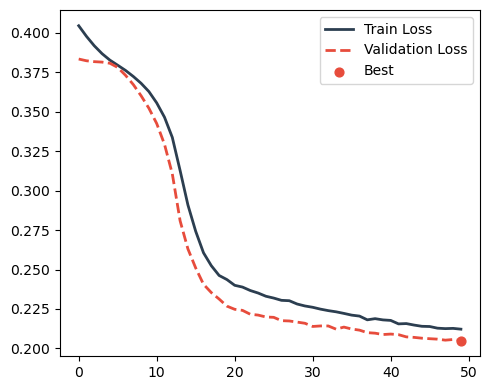

In [277]:
plt.figure(figsize=(5, 4))
sns.lineplot(history['loss'], label='Train Loss', color=TRAIN_COLOR, linewidth=2)
sns.lineplot(history['val_loss'], label='Validation Loss', color=VALID_COLOR, linewidth=2, linestyle='--')
best_epoch = history['val_loss'].index(min(history['val_loss']))
plt.scatter(best_epoch, history['val_loss'][best_epoch], s=40, label='Best', color=VALID_COLOR)
plt.legend()
plt.tight_layout()

#### Evaluate Model

In [278]:
loss, pred = run(model, dataloader_test, criterion, device=DEVICE, is_train=False, out_preds=True)

In [279]:
print(f"Test Loss: {loss:.2f}")

Test Loss: 0.15


In [280]:
pred_df = pd.DataFrame(
    {
        'true': test[WINDOW_SIZE:][PREDICT_COL],
        'pred': y_scaler.inverse_transform(pred).squeeze()
    }
)

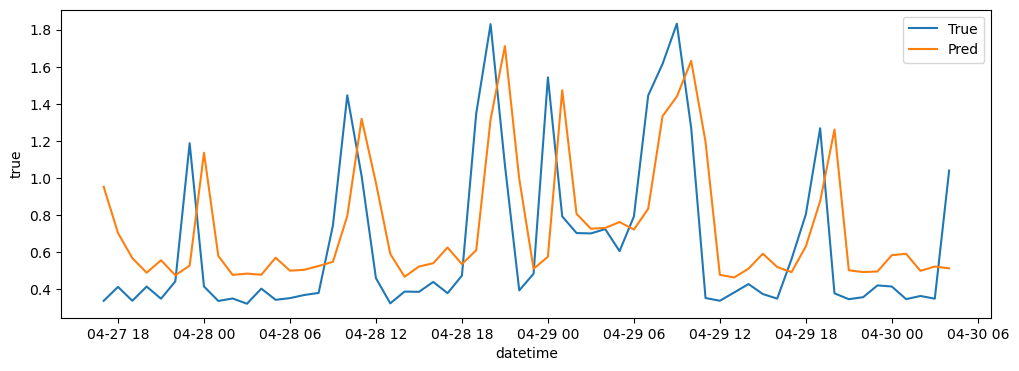

In [281]:
plt.figure(figsize=(12, 4))
sns.lineplot(x=pred_df.index[:60], y='true', data=pred_df[:60], label='True')
sns.lineplot(x=pred_df.index[:60], y='pred', data=pred_df[:60], label='Pred')
plt.legend()